In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

In [3]:
df = pd.read_csv("weekly_model_multiple_runs.csv")

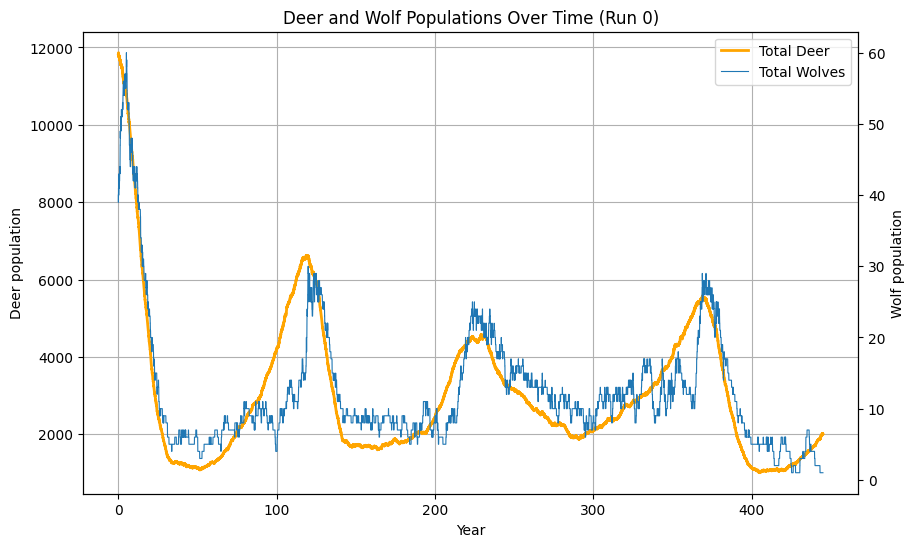

In [4]:
run_id = 0
df = df[df["Run"] == run_id].copy()

fig, ax1 = plt.subplots(figsize=(10, 6))
ax2 = ax1.twinx()

ax1.plot(df["Year"], df["Total Deer"], label="Total Deer", color="orange", linewidth=2)
ax2.plot(df["Year"], df["Total Wolves"], label="Total Wolves", linewidth=0.8)

ax1.set_xlabel("Year")
ax1.set_ylabel("Deer population")
ax2.set_ylabel("Wolf population")
ax1.set_title(f"Deer and Wolf Populations Over Time (Run {run_id})")



lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper right")

ax1.grid(True)
plt.show()

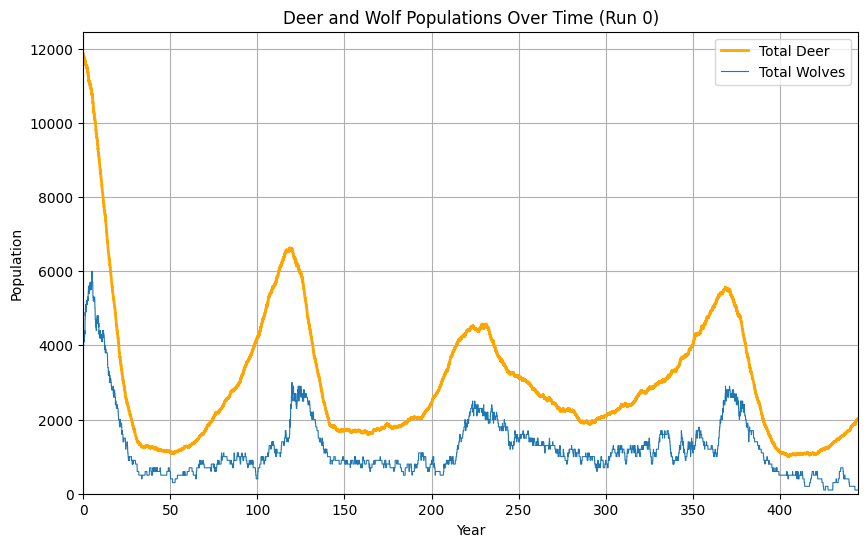

In [5]:

run_id = 0
df = df[df["Run"] == run_id].copy().reset_index(drop=True)

if "Year" not in df.columns:
    if "Step" in df.columns:
        df["Year"] = df["Step"] / 52
    else:
        df["Year"] = df.index / 52

fig, ax = plt.subplots(figsize=(10, 6))


ax.plot(df["Year"], df["Total Deer"], label="Total Deer", color="orange", linewidth=2)
ax.plot(df["Year"], df["Total Wolves"]*100, label="Total Wolves", linewidth=0.8)

ax.set_xlabel("Year")
ax.set_ylabel("Population")
ax.set_title(f"Deer and Wolf Populations Over Time (Run {run_id})")
ax.legend()
ax.grid(True)

ax.set_xlim(df["Year"].min(), df["Year"].max())
ax.set_ylim(0, max(df["Total Deer"].max(), df["Total Wolves"].max()) * 1.05)



plt.show()

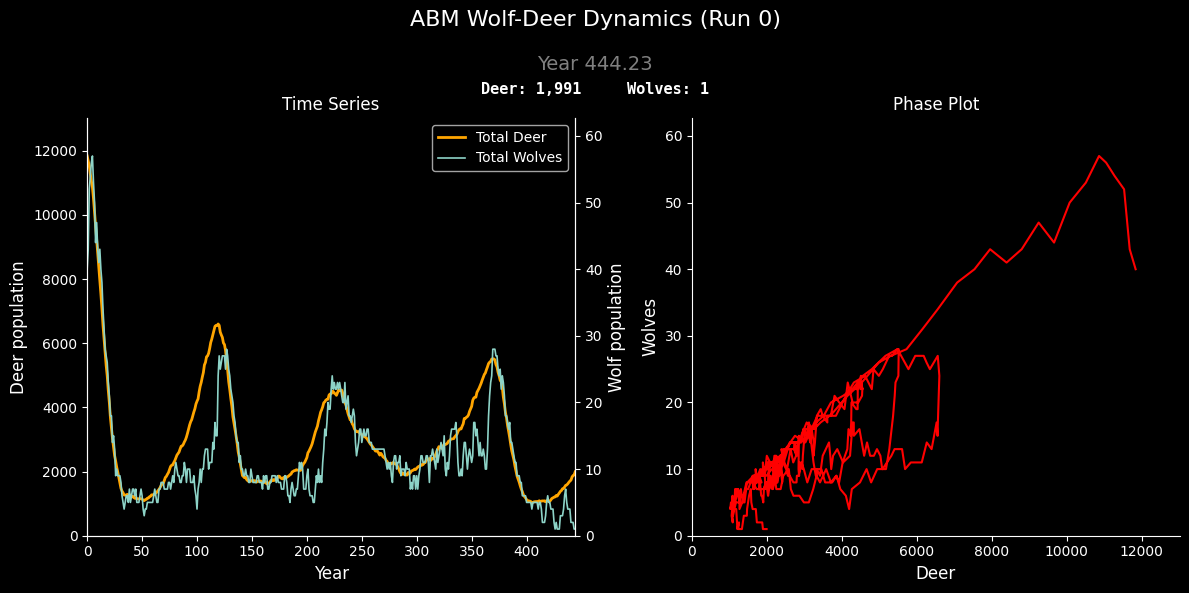

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

plt.style.use("dark_background")

# Load data
df = pd.read_csv("weekly_model_multiple_runs.csv")

# Choose run
run_id = 0
run_df = df[df["Run"] == run_id].copy().reset_index(drop=True)
run_df = run_df.iloc[::500].reset_index(drop=True)

# Extract columns using your saved names
t = run_df["Year"].values
deer = run_df["Total Deer"].values
wolves = run_df["Total Wolves"].values

# Create figure and axes
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

# Time series axis labels
ax1.set_xlabel("Year", fontsize=12)
ax1.set_ylabel("Deer population", fontsize=12)

# Create second y-axis for wolves on time series plot
ax1b = ax1.twinx()
ax1b.set_ylabel("Wolf population", fontsize=12)

# Phase plot labels
ax2.set_xlabel("Deer", fontsize=12)
ax2.set_ylabel("Wolves", fontsize=12)

# Set limits
ax1.set_xlim(t[0], t[-1])
ax1.set_ylim(0, deer.max() * 1.1)
ax1b.set_ylim(0, wolves.max() * 1.1)

ax2.set_xlim(0, deer.max() * 1.1)
ax2.set_ylim(0, wolves.max() * 1.1)

# Clean spines
ax1.spines["top"].set_visible(False)
ax2.spines["top"].set_visible(False)
ax2.spines["right"].set_visible(False)
ax1b.spines["top"].set_visible(False)

# Titles
ax1.set_title("Time Series")
ax2.set_title("Phase Plot")
fig.suptitle(f"ABM Wolf-Deer Dynamics (Run {run_id})", y=0.98, fontsize=16)

# Create empty animated lines
line_deer, = ax1.plot([], [], label="Total Deer", color="orange", linewidth=2)
line_wolf, = ax1b.plot([], [], label="Total Wolves", linewidth=1.2)
line_phase, = ax2.plot([], [], color="red", linewidth=1.5)

# Combined legend for time series
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax1b.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper right")

# Text annotations
pop_text = fig.text(
    0.5, 0.84, '',
    ha='center',
    fontsize=11,
    fontfamily='monospace',
    fontweight='bold'
)

time_text = fig.text(
    0.5, 0.88, '',
    ha='center',
    fontsize=14,
    color='gray'
)

# Animation function
def animate(frame):
    line_deer.set_data(t[:frame + 1], deer[:frame + 1])
    line_wolf.set_data(t[:frame + 1], wolves[:frame + 1])
    line_phase.set_data(deer[:frame + 1], wolves[:frame + 1])

    time_text.set_text(f"Year {t[frame]:.2f}")
    pop_text.set_text(
        f"Deer: {int(deer[frame]):,}     Wolves: {int(wolves[frame]):,}"
    )

    return line_deer, line_wolf, line_phase, time_text, pop_text

# Build animation
ani = FuncAnimation(fig, animate, frames=len(t), repeat=False)

fig.tight_layout()
plt.subplots_adjust(top=0.8)

# Save gif
ani.save("abm_population.gif", writer="pillow", fps=10)

plt.show()